<!-- 
# Time spent
|  Name  | Time   |
| ---    |  ---   |
| Danylo | 40 min |
| Ivan   | 5 min  |
| Daryna | 0 min  |
-->
**Course**: Computational Social Science, Homework #2  
**Team**: FightClub  
**Research topic**: Brainrot analysis  
**Lecturer**: Andrew Kurochkin  
**Date**: October 2026  
**Place**: National University of Kyiv-Mohyla Academy, Faculty of Informatics

# Table of contents
0. [Overview](#Overview)
    1. Hypotheses
    2. Datasets
1. H1: Discourse is getting shorter and simpler
    1. Overview
    2. Activity and distribution
    3. Content analysis
    4. Interesting findings
2. H3: Wellbeing is getting worse among doomscrollers
3. H4: Crises intensify doomscrolling and negativity
4. Result

# 0. Overview
Since our goal is many-sided and has certain specific characteristics, we will follow our own flow with exploration and analysis of data. We already have hypotheses to test and we will try to find approaches in order to prove those hypothese right or wrong. We will not follow guidelines or try to check any boxes, instead we will follow our curiosity and play until we have the answer.

However, there is one guideline: before freestyling with analysis - explore the data and brainstorm what visualizations should be made.

Since we have 4 different hypotheses to test, the research is structured into 4 independent parts, each of them testing one hypothesis and doing separate data overview. Each hypothesis is tested with separate datasets and those datasets are reviewed independently in each of 4 parts. After that some of the results and findings are merged.

## Hypotheses
Our topic is analysis of impact of doomscrolling and brainrot on people, discourse, their wellbeing and cognitive abilities over time. We study the effects of doomscrolling with the hypotheses below.

- H1: Discourse is getting shorter and simpler
    - Lexical & NLP approach
    - Temporal/Behavioral aspect
- H2: Short-form platforms accelerated the degradation of discourse
- H3: Wellbeing is getting worse among doomscrollers
- H4: Crises intensify doomscrolling and negativity

## Datasets
Each hypothesis is proven by using different datasets.

### H1: Discourse is getting shorter and simpler  
Comments and submissions from reddit, collected from 01.2012 to 09.2026, divided into different categories.

1. Short-form: r/memes, r/teenagers
2. Long-form: r/books, r/explainlikeimfive
3. Baseline: r/todayilearned
4. Qualitative: r/nosurf

### H2: Short-form platforms accelerated the degradation of discourse
1. [Reels/Shorts Consumption vs Attention Span](https://www.kaggle.com/datasets/jayjoshi37/reelsshorts-consumption-vs-attention-span)

### H3: Wellbeing is getting worse among doomscrollers
1. [Social Media Addiction dataset](https://www.kaggle.com/datasets/engieid/social-media-addiction-dataset)
2. [The Dark At The End Of The Tunnel: Doomscrolling On Social Media Newsfeeds](https://osf.io/u9f6h/)
3. [Sleep & Doomscrolling Habits Dataset](https://www.kaggle.com/datasets/harpartapsingh13/sleep-and-doomscrolling-habits-dataset)
4. [Social Media and Mental Health](https://www.kaggle.com/datasets/souvikahmed071/social-media-and-mental-health)
5. [Student Social Media & Mental Health](https://www.kaggle.com/datasets/shivasingh4945/student-social-media-and-mental-health-impact)

### H4: Crises intensify doomscrolling and negativity


## Additional approaches
- questionnaire
- YouTube comments

# 1. H1: Discourse is getting shorter and simpler
> Only Danylo works below
Time spent: 665min

In this section we test this hypothesis with data. We'll be analyzing the discourse of a dataset of 9.2 million comments and 1.8 million submissions that were posted on reddit between 2012 and 2026.

Before getting into data and into analysis, in order to pick the correct analysis path, let's take a bird's-eye view of our data and on our goal. We want to verify that over the 14 years discourse has been getting shorter and simpler. In order to check that, we have two approaches:

1. **Lexical & NLP approach**
2. **Temporal/Behavioral aspect**

In **Lexical & NLP approach** we analyse sentences and check the following metrics:

1. Vocabulary is shrinking
2. Sentences are getting shorter
    1. Words per comment
    2. Words per sentence
3. Lempel-Ziv algorithm
    1. Concatenation of comments into fixed-size chunks per subreddit per month

In **Temporal/Behavioral aspect** we analyze conversantions and look into:

1. Thread depth
    1. Thread size
    2. Share or replies vs top-level comments
    3. True depth <!-- download full month for that -->

Ideas for analysis:

1. Readability (Flesch-Kincaid)
2. Avg word length

## 1.1. Overview
Our dataset consists of 9,237,205 comments and 1,870,257 posts, collected from 01.2012 to 09.2026, from these subreddits:

1. Short-form: r/memes, r/teenagers
2. Long-form: r/books, r/explainlikeimfive
3. Baseline: r/todayilearned
4. Qualitative: r/nosurf

Dataset was downloaded from [Arctic Shift API](https://arctic-shift.photon-reddit.com/). We didn't download full dataset of comments and posts because of the size and downloading time. Instead, we sampled 10,000 comments per subreddit per month and 2,000 posts per subreddit per month. Samples are downloaded from random time slots. Each month is cut into equal time slots, each slot holding roughly 1,000 comments or 200 posts. For our subreddits total amount of comments is 346.4 million and total amount of posts is 27.3 million. Our sample covers about 2.7% of all comments and 6.9% of all posts.


In [9]:
"""
!Important!
Libraries needed:
 - 


Overview here:
- number of records
- timeframe
"""

"""
1. Setup
"""
from pathlib import Path
import duckdb
import pandas as pd

DATA = Path("data/reddit_arctic")
con = duckdb.connect()
con.sql("SET TimeZone = 'UTC'")   # Reddit timestamps are UTC; without this DuckDB uses your computer's time zone

FOLDERS = {"comments": "comments", "posts": "submissions"}
for view, folder in FOLDERS.items():
    con.sql(f"""CREATE OR REPLACE VIEW {view} AS
                SELECT * FROM read_parquet('{(DATA / folder).as_posix()}/**/*.parquet', hive_partitioning=false)""")

In [10]:
"""
2. Number of records, timeframe, size
"""
rows = []
for view, folder in FOLDERS.items():
    files = list((DATA / folder).rglob("*.parquet"))
    stats = con.sql(f"""
        SELECT count(*)                                                     AS records,
               count(DISTINCT subreddit)                                    AS subreddits,
               min(to_timestamp(created_utc))::DATE                         AS first_record,
               max(to_timestamp(created_utc))::DATE                         AS last_record,
               count(DISTINCT strftime(to_timestamp(created_utc), '%Y-%m')) AS months
        FROM {view}""").df().iloc[0].to_dict()
    rows.append({"type": view, **stats, "files": len(files),
                 "size_MB": round(sum(f.stat().st_size for f in files) / 1024**2, 1)})
overview = pd.DataFrame(rows).set_index("type")
overview

,records,subreddits,first_record,last_record,months,files,size_MB
type,,,,,,,
comments,9237205,6,2012-01-01,2026-09-30,177,1062,897.5
posts,1870257,6,2012-01-01,2026-09-30,177,1062,225.4


In [11]:
"""
3. Per subreddit, the sample vs everything on Reddit
"""
totals = pd.read_csv(DATA / "_monthly_totals.csv")
per_sub = []
for view, total_col in [("comments", "comments_total"), ("posts", "posts_total")]:
    s = con.sql(f"""SELECT subreddit, strftime(to_timestamp(created_utc), '%Y-%m') AS month, count(*) AS sampled
                    FROM {view} GROUP BY ALL""").df()
    m = totals[["subreddit", "month", total_col]].merge(s, on=["subreddit", "month"], how="left").fillna({"sampled": 0})
    g = m.groupby("subreddit").agg(sampled=("sampled", "sum"), total=(total_col, "sum"),
                                   first_month=("month", "min"), last_month=("month", "max"))
    g["coverage_%"] = (100 * g["sampled"] / g["total"]).round(1)
    g["complete_months"] = (m["sampled"] >= 0.99 * m[total_col]).groupby(m["subreddit"]).sum()
    g.columns = pd.MultiIndex.from_product([[view], g.columns])
    per_sub.append(g)
per_sub = pd.concat(per_sub, axis=1)
per_sub

comments                                               \
                   sampled      total first_month last_month coverage_%   
subreddit                                                                 
books              1876751   13137631     2012-01    2026-09       14.3   
explainlikeimfive  1852536   21058471     2012-01    2026-09        8.8   
memes              1334537  108528872     2012-01    2026-09        1.2   
nosurf              478540     478745     2012-01    2026-09      100.0   
teenagers          1843775  133272831     2012-01    2026-09        1.4   
todayilearned      1851066   69926671     2012-01    2026-09        2.6   

                                      posts                                   \
                  complete_months   sampled     total first_month last_month   
subreddit                                                                      
books                           0  368255.0    890216     2012-01    2026-09   
explainlikeimfive               0  369085.0   2000253     2012-01    2026-09   
memes                          62  343402.0  11858295     2012-01    2026-09   
nosurf                        177   56057.0     56082     2012-01    2026-09   
teenagers                       0  363975.0  10305407     2012-01    2026-09   
todayilearned                   0  369483.0   2162300     2012-01    2026-09   

                                              
                  coverage_% complete_months  
subreddit                                     
books                   41.4               0  
explainlikeimfive       18.5               0  
memes                    2.9              38  
nosurf                 100.0             177  
teenagers                3.5               8  
todayilearned           17.1               0

## 1.2. Activity and distribution
Before analysing the datasets, let's explore the activity over the last 14 years. First 2 plots represent the streamgraphs of comments and posts per day for all subreddit in absolute values. In August 2018 TikTok global, in March 2020 COVID-19 took place and TikTok went viral during the same period of time, as can seen on the streamgraph.

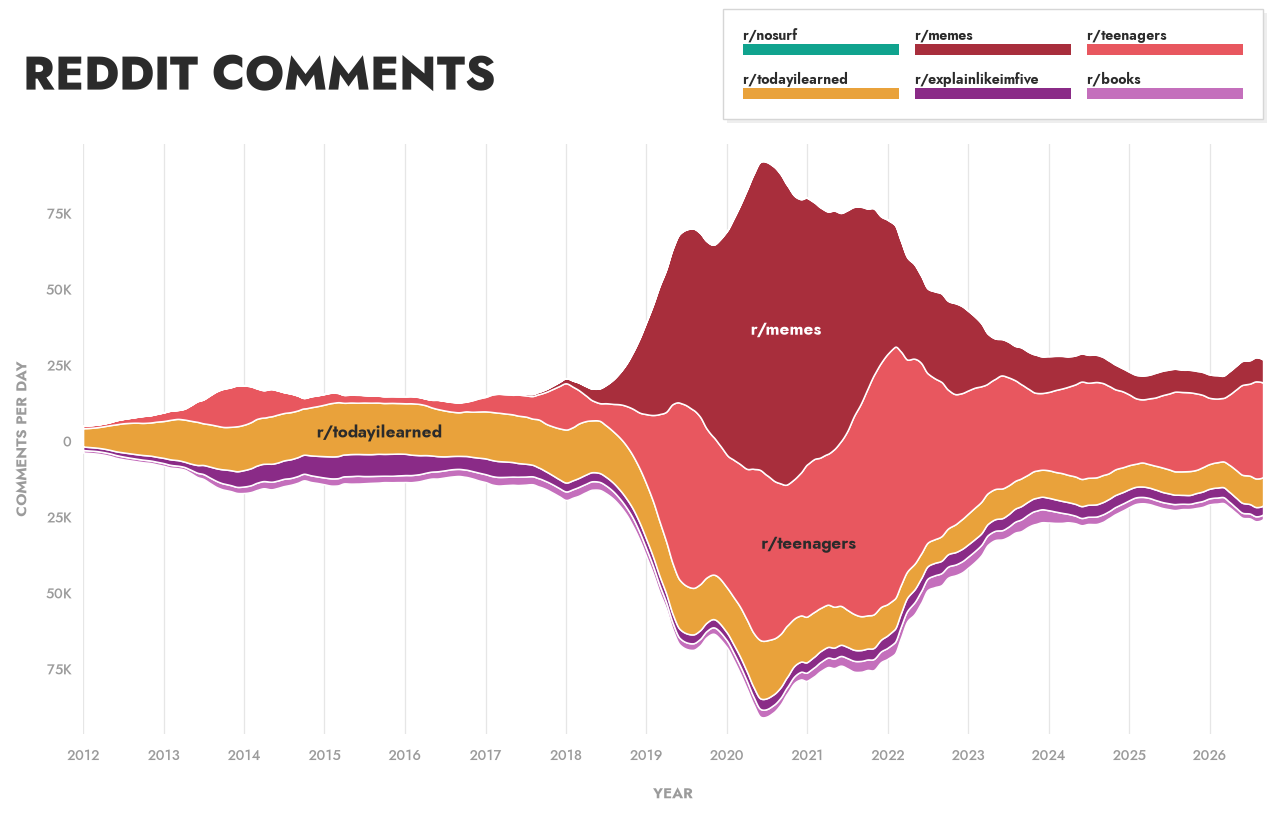

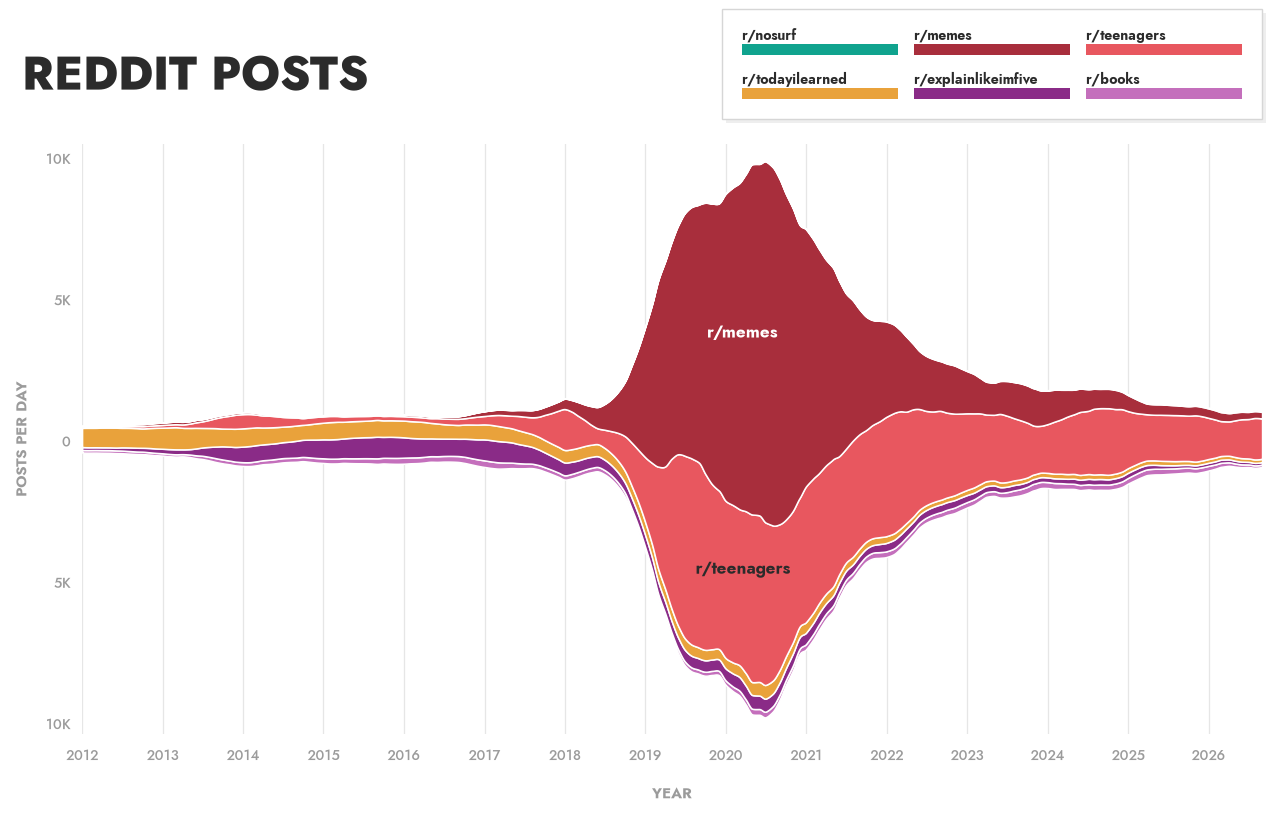

In [12]:
# Libraries: pandas, numpy, matplotlib, scipy   (pip install scipy, if missing)
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib import font_manager
from matplotlib.patches import Rectangle
from scipy.interpolate import PchipInterpolator

DATA = Path("data/reddit_arctic")


# ---- font: Jost, loaded straight from its .ttf files ------------------------------------------------------------
def find_jost():
    """Folder with Jost-Bold.ttf: looks in fonts/ (any subfolder) next to the notebook and up to two folders above."""
    for base in [Path.cwd(), *list(Path.cwd().parents)[:2]]:
        for pattern in ("fonts/**/Jost-Bold.ttf", "jost_fonts/**/Jost-Bold.ttf"):
            hit = next(base.glob(pattern), None)
            if hit:
                return hit.parent
    return None


JOST_DIR = find_jost()
JOST_FILES = {"light": "Jost-Light.ttf", "regular": "Jost-Medium.ttf", "medium": "Jost-Medium.ttf",
              "semibold": "Jost-SemiBold.ttf", "bold": "Jost-Bold.ttf", "heavy": "Jost-ExtraBold.ttf"}
if JOST_DIR is None:
    _installed = {f.name for f in font_manager.fontManager.ttflist}
    FALLBACK = next((f for f in ["Futura", "Century Gothic", "Avenir Next", "Arial"] if f in _installed), "DejaVu Sans")
    print(f"Jost not found (expected fonts/Jost-*.ttf in {Path.cwd()}); using {FALLBACK} instead.")


def font(weight, size):
    if JOST_DIR is not None and (JOST_DIR / JOST_FILES[weight]).exists():
        return font_manager.FontProperties(fname=JOST_DIR / JOST_FILES[weight], size=size)
    # fallback fonts usually have only regular and bold - asking for other weights causes "findfont" warnings
    return font_manager.FontProperties(family=FALLBACK, size=size,
                                       weight="bold" if weight in ("semibold", "bold", "heavy") else "normal")


# ---- colours and shared helpers -----------------------------------------------------------------------------
STREAMS = [  # bottom -> top; colours checked for colour-blind safety in this order
    ("books", "#C46FBC"),
    ("explainlikeimfive", "#8A2B87"),
    ("todayilearned", "#E9A23B"),
    ("teenagers", "#E8575F"),
    ("memes", "#A82E3C"),
    ("nosurf", "#10A38E"),
]
WRAPPED = {"explainlikeimfive": "r/explain\nlikeimfive", "todayilearned": "r/today\nilearned"}
AREA_ALPHA = 1                                     # areas very slightly transparent
INK, AXIS_TEXT, GRID = "#2b2b2b", "#9b9b9b", "#e6e6e6"


def compact(v, _=None):
    v = abs(v)
    return f"{v / 1e6:g}M" if v >= 1e6 else f"{v / 1e3:g}K" if v >= 1e3 else f"{v:g}"


def label_color(fill, alpha=AREA_ALPHA):
    """White or dark text, whichever contrasts more with the (slightly transparent) fill on white."""
    rgb = [alpha * int(fill[i:i + 2], 16) / 255 + (1 - alpha) for i in (1, 3, 5)]
    lin = [c / 12.92 if c <= 0.03928 else ((c + 0.055) / 1.055) ** 2.4 for c in rgb]
    lum = 0.2126 * lin[0] + 0.7152 * lin[1] + 0.0722 * lin[2]
    return "white" if 1.05 / (lum + 0.05) >= (lum + 0.05) / 0.074 else INK


def base_figure(title, ylabel):
    """Figure with the plot area, title (top left) and legend (top right) in the reference style."""
    fig = plt.figure(figsize=(13, 8.4), facecolor="white")
    W, H = fig.get_size_inches()
    ax = fig.add_axes([0.95 / W, 0.85 / H, 1 - 1.2 / W, 1 - (0.85 + 1.65) / H])
    fig.text(0.35 / W, 1 - 0.6 / H, title, fontproperties=font("heavy", 34), color=INK, va="top")
    ax.set_xlabel("YEAR", fontproperties=font("bold", 11), color=AXIS_TEXT, labelpad=12)
    ax.set_ylabel(ylabel, fontproperties=font("bold", 11), color=AXIS_TEXT, labelpad=10)

    # legend: framed box, every entry = caption above a colour bar (3 x 2), same order as the bands top to bottom
    entries = list(reversed(STREAMS))
    ncol, col_w, row_h, pad = 3, 1.72, 0.44, 0.2                     # inches
    box_w, box_h = ncol * col_w + 2 * pad - 0.16, -(-len(entries) // ncol) * row_h + 0.22
    lg = fig.add_axes([(W - 0.25 - box_w) / W, (H - 0.3 - box_h) / H, box_w / W, box_h / H])
    lg.set_xlim(0, box_w)
    lg.set_ylim(0, box_h)
    lg.axis("off")
    lg.add_patch(Rectangle((0.04, -0.04), box_w, box_h, facecolor="#eeeeee", edgecolor="none", clip_on=False, zorder=0))
    lg.add_patch(Rectangle((0, 0), box_w, box_h, facecolor="white", edgecolor="#d6d6d6", linewidth=1, clip_on=False, zorder=1))
    for i, (s, c) in enumerate(entries):
        x0, y0 = pad + (i % ncol) * col_w, box_h - 0.16 - (i // ncol) * row_h
        lg.text(x0, y0, f"r/{s}", fontproperties=font("bold", 10), color=INK, va="top", ha="left", zorder=2)
        lg.add_patch(Rectangle((x0, y0 - 0.3), col_w - 0.16, 0.11, facecolor=c, alpha=AREA_ALPHA,
                               edgecolor="none", zorder=2))
    return fig, ax


def style_axes(ax, xs, index):
    years = pd.date_range(index[0], index[-1], freq="YS")
    ax.set_xticks(mdates.date2num(years), [str(y.year) for y in years])
    ax.set_xlim(xs[0], xs[-1])
    ax.grid(axis="x", color=GRID, linewidth=0.9, zorder=0)
    ax.grid(axis="y", visible=False)
    for side in ax.spines.values():
        side.set_visible(False)
    ax.tick_params(length=0, pad=8)
    for lab in ax.get_xticklabels():
        lab.set_fontproperties(font("regular", 10))
        lab.set_color(AXIS_TEXT)


def style_y_labels(ax):
    for lab in ax.get_yticklabels():
        lab.set_fontproperties(font("regular", 10))
        lab.set_color(AXIS_TEXT)


def smooth(per_day, smooth_months=5):
    """Monthly values -> smooth curves on a dense grid (5-month moving average + shape-preserving interpolation)."""
    v = per_day[[s for s, _ in STREAMS]].rolling(smooth_months, center=True, min_periods=1).mean()
    x = mdates.date2num(v.index)
    xs = np.linspace(x[0], x[-1], len(x) * 10)
    ys = np.array([np.clip(PchipInterpolator(x, v[s].to_numpy())(xs), 0, None) for s in v.columns])
    return xs, ys


def label_bands(ax, xs, lower, upper, sizes=(12, 10)):
    """Write each subreddit's name inside its band, where the band is widest. Bands too thin for text get none."""
    W, H = ax.figure.get_size_inches()
    pos = ax.get_position()
    ax_w, ax_h = pos.width * W, pos.height * H
    y_per_inch = np.diff(ax.get_ylim())[0] / ax_h
    step = xs[1] - xs[0]
    for i, (s, c) in enumerate(STREAMS):
        candidates = [(size, text) for size in sizes for text in (f"r/{s}", WRAPPED.get(s)) if text]
        for size, text in candidates:
            n_lines = text.count("\n") + 1
            width_in = max(map(len, text.split("\n"))) * size * 0.6 / 72 + 0.3
            need = (n_lines * size * 1.25 / 72 + 0.1) * y_per_inch
            win = max(3, int(width_in / ax_w * (xs[-1] - xs[0]) / step))
            floor = pd.Series(lower[i]).rolling(win, center=True).max()      # highest lower edge under the text
            ceil = pd.Series(upper[i]).rolling(win, center=True).min()       # lowest upper edge under the text
            room = (ceil - floor).to_numpy()
            if np.nanmax(room) >= need:
                j = int(np.nanargmax(room))
                ax.text(xs[j], (floor[j] + ceil[j]) / 2, text, ha="center", va="center", linespacing=1.1,
                        fontproperties=font("bold", size), color=label_color(c), zorder=4)
                break


# ---- streamgraph --------------------------------------------------------------------------------------------
def streamgraph(per_day, title, ylabel):
    """Streams centred on a horizontal axis; y-axis = absolute values measured from the centre line."""
    xs, ys = smooth(per_day)
    fig, ax = base_figure(title, ylabel)
    ax.stackplot(xs, *ys, baseline="sym", colors=[c for _, c in STREAMS], alpha=AREA_ALPHA,
                 edgecolor="white", linewidth=1.1, zorder=2)
    style_axes(ax, xs, per_day.index)
    top = ys.sum(axis=0).max() / 2 * 1.06
    ax.set_ylim(-top, top)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=8, symmetric=True, steps=[1, 2, 2.5, 5, 10]))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(compact))
    style_y_labels(ax)
    lower = -ys.sum(axis=0) / 2 + np.vstack([np.zeros(len(xs)), np.cumsum(ys, axis=0)[:-1]])
    label_bands(ax, xs, lower, lower + ys)
    plt.show()


monthly = pd.read_csv(DATA / "_monthly_totals.csv", parse_dates=["month"])
days = monthly["month"].dt.days_in_month
comments_per_day = monthly.assign(v=monthly["comments_total"] / days).pivot(index="month", columns="subreddit", values="v")
posts_per_day = monthly.assign(v=monthly["posts_total"] / days).pivot(index="month", columns="subreddit", values="v")

streamgraph(comments_per_day, "REDDIT COMMENTS", "COMMENTS PER DAY")
streamgraph(posts_per_day, "REDDIT POSTS", "POSTS PER DAY")

Let's take a look at stacked area chart which represents the activity of comments and posts per day for all subreddit, but in relative values.

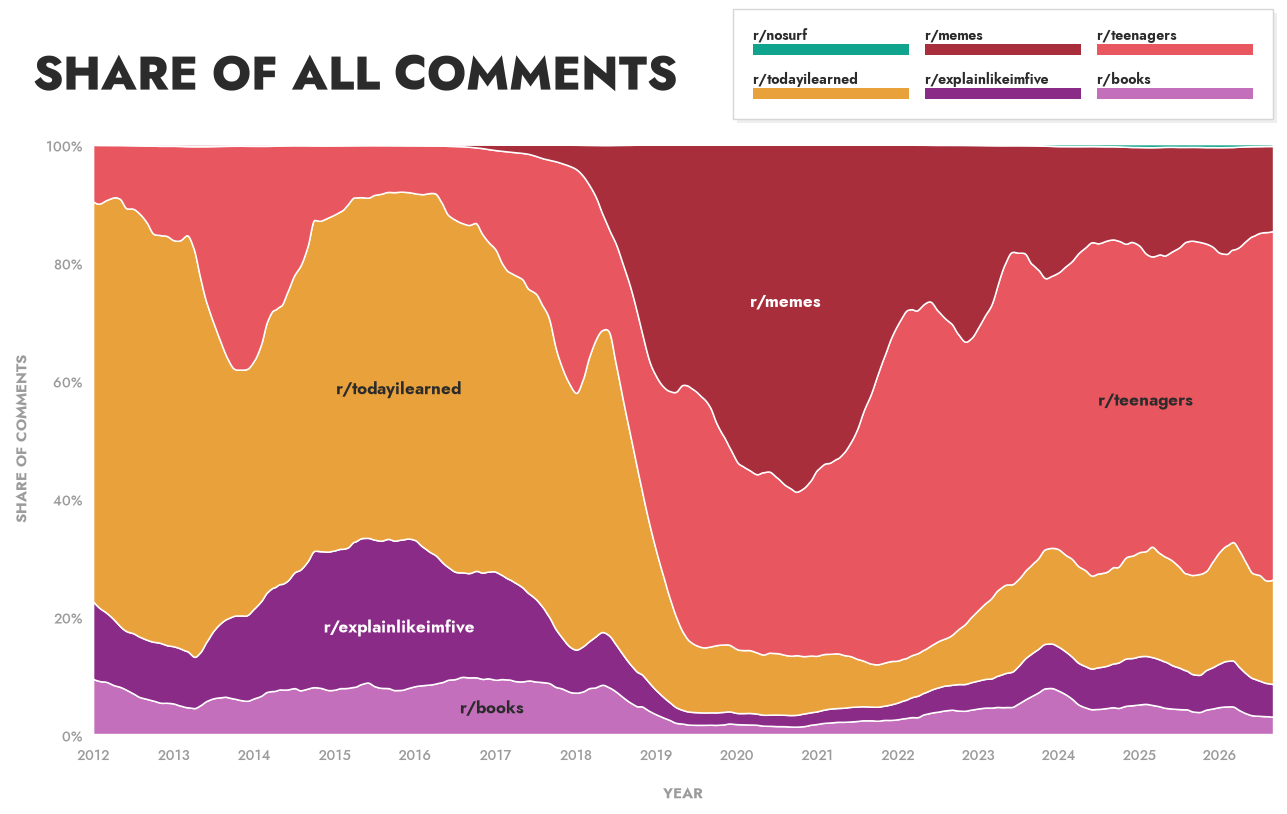

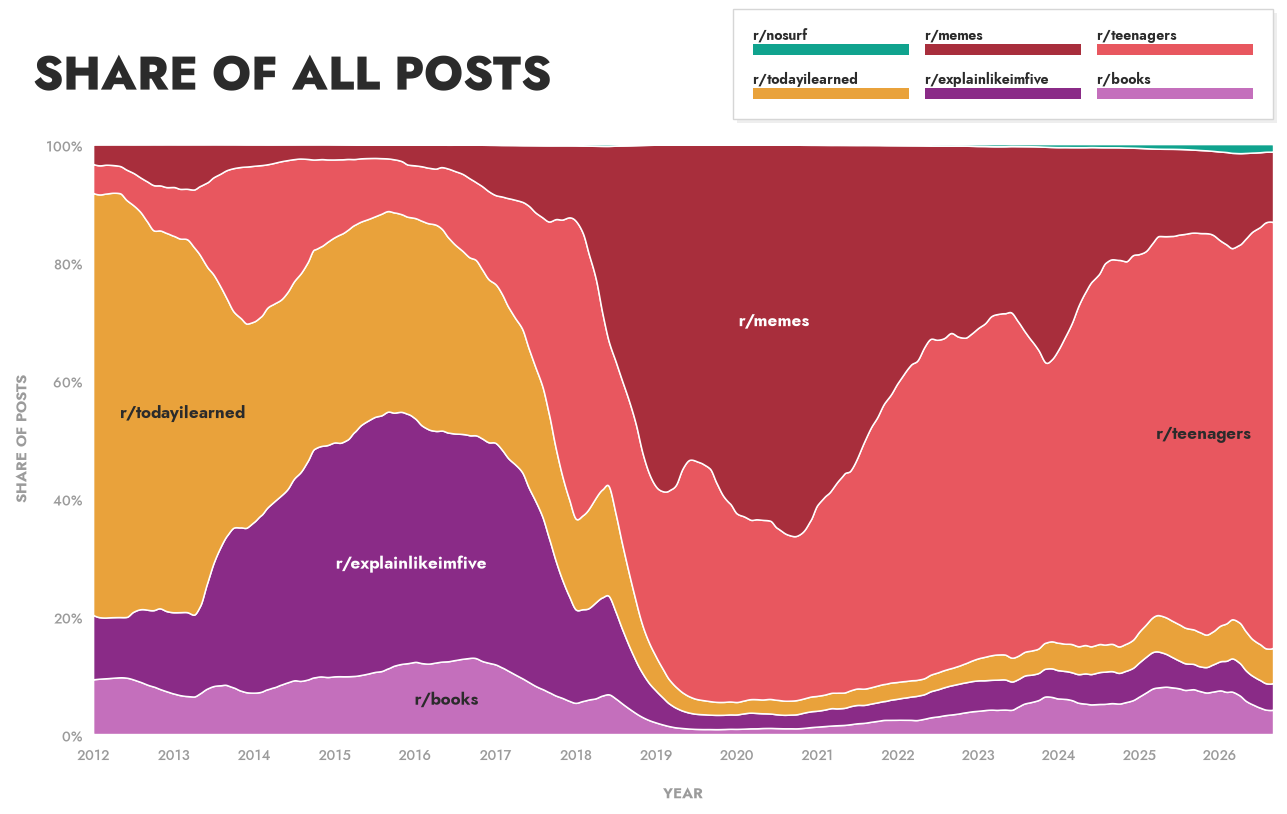

In [13]:
def share_chart(per_day, title, ylabel):
    """100% stacked area: each subreddit's share of the six subreddits' total, names inside the bands."""
    xs, ys = smooth(per_day)
    share = ys / ys.sum(axis=0)                                       # every column sums to 100%
    fig, ax = base_figure(title, ylabel)
    ax.stackplot(xs, *share, colors=[c for _, c in STREAMS], alpha=AREA_ALPHA,
                 edgecolor="white", linewidth=1.1, zorder=2)
    style_axes(ax, xs, per_day.index)
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    style_y_labels(ax)
    lower = np.vstack([np.zeros(len(xs)), np.cumsum(share, axis=0)[:-1]])
    label_bands(ax, xs, lower, lower + share)
    plt.show()


share_chart(comments_per_day, "SHARE OF ALL COMMENTS", "SHARE OF COMMENTS")
share_chart(posts_per_day, "SHARE OF ALL POSTS", "SHARE OF POSTS")

Below is a ridgeline chart which represents the activity of each subreddit individually in gradient in absolute values.

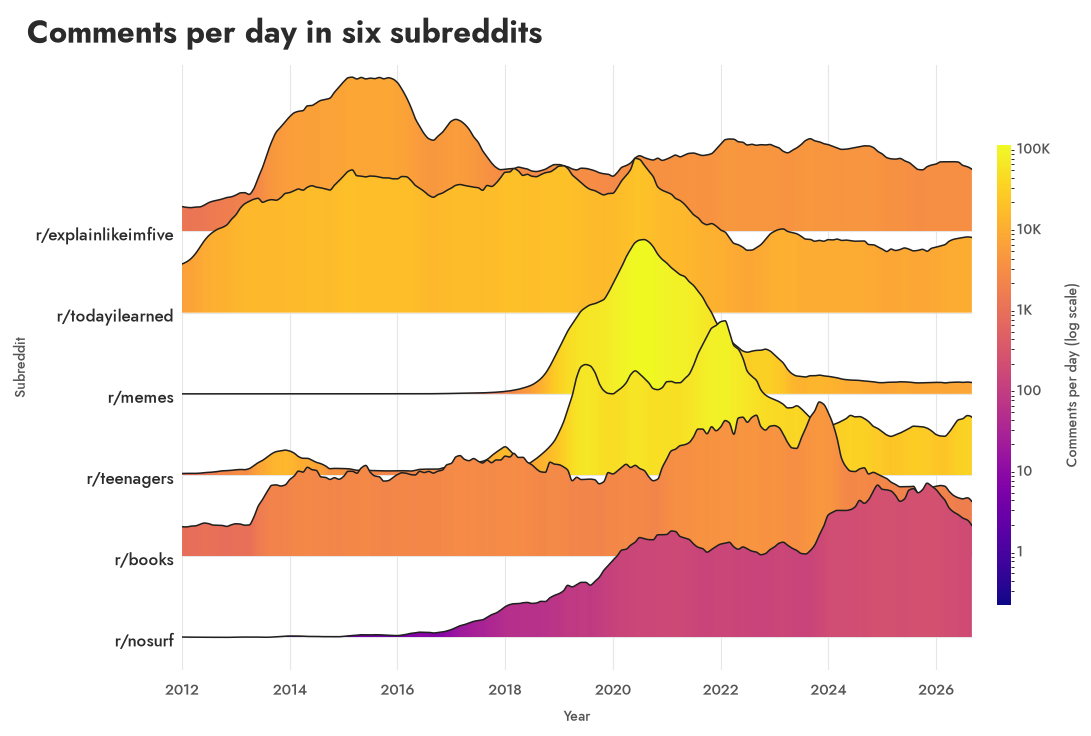

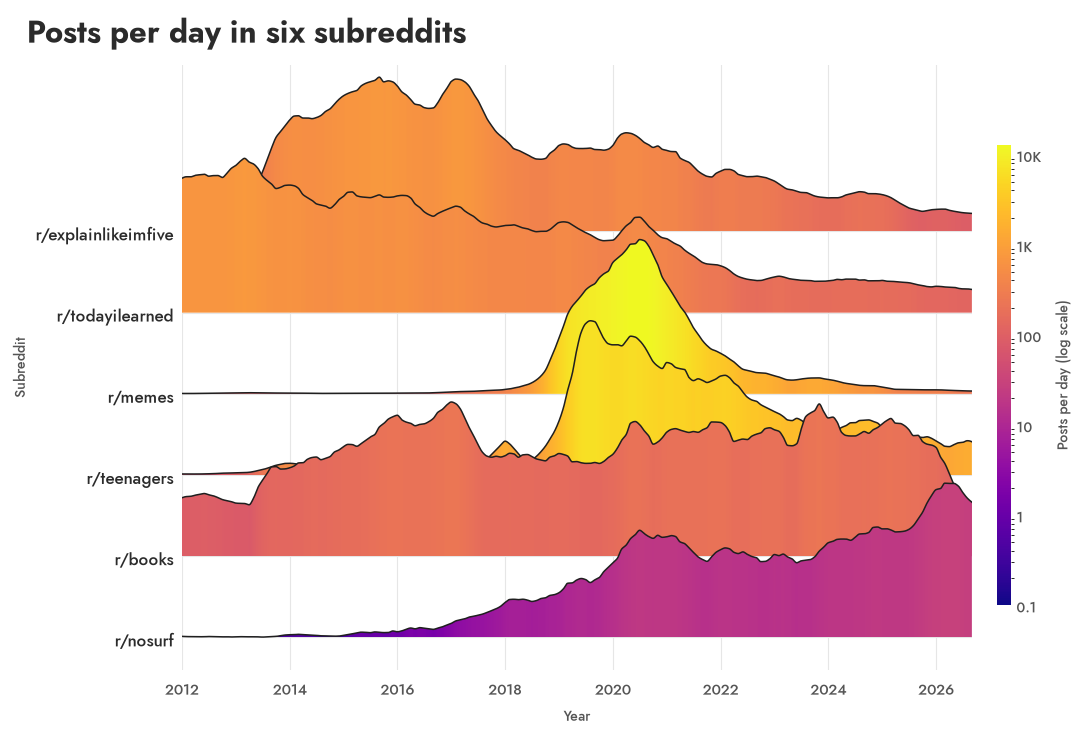

In [14]:
# Run after the streamgraph cell: uses its font(), smooth(), STREAMS, colours, comments_per_day and posts_per_day.
from matplotlib.colors import LogNorm
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Polygon

RIDGE_CMAP = plt.get_cmap("plasma")
INK2_RIDGE = "#555555"


def ridgeline(per_day, title, unit, order=None, overlap=1.9):
    """One ridge per subreddit. Height: activity relative to the subreddit's own busiest month.
    Colour: the actual activity per day at that moment, on one log scale shared by all ridges."""
    xs, ys = smooth(per_day)                                       # same smoothing as the streamgraphs
    subs = [s for s, _ in STREAMS]
    values = dict(zip(subs, ys))
    if order is None:                                               # earliest peak at the top
        order = sorted(subs, key=lambda s: xs[np.argmax(values[s])])

    positive = np.concatenate([v[v > 0] for v in values.values()])
    norm = LogNorm(vmin=max(positive.min(), 0.1), vmax=positive.max())

    fig = plt.figure(figsize=(11, 7.6), facecolor="white")
    W, H = fig.get_size_inches()
    ax = fig.add_axes([1.85 / W, 0.75 / H, (W - 3.1) / W, (H - 1.55) / H])
    cax = fig.add_axes([(W - 1.0) / W, 1.4 / H, 0.14 / W, (H - 3.0) / H])

    n = len(order)
    for i, s in enumerate(order):                                   # top row first; lower rows drawn in front
        base = n - 1 - i
        v = values[s]
        top = base + overlap * v / v.max()
        z = 2 + 2 * i
        ridge = Polygon(np.column_stack([np.r_[xs, xs[::-1]], np.r_[top, np.full_like(xs, base)]]),
                        facecolor="none", edgecolor="none", transform=ax.transData)
        ax.add_patch(ridge)
        colours = RIDGE_CMAP(norm(np.clip(v, norm.vmin, None)))[np.newaxis, :, :]
        img = ax.imshow(colours, extent=[xs[0], xs[-1], base, base + overlap], aspect="auto",
                        origin="lower", interpolation="bilinear", zorder=z)
        img.set_clip_path(ridge)                                    # gradient only inside the ridge
        ax.plot(xs, top, color="#1f1f1f", linewidth=1.1, zorder=z + 1)

    # axes in the style of the reference: light grid, row names on the left, small axis titles
    years = pd.date_range(per_day.index[0], per_day.index[-1], freq="2YS")
    ax.set_xticks(mdates.date2num(years), [str(y.year) for y in years])
    ax.set_yticks(range(n), [f"r/{s}" for s in reversed(order)])
    ax.set_xlim(xs[0], xs[-1])
    ax.set_ylim(-0.4, n - 1 + overlap + 0.15)
    ax.grid(color=GRID, linewidth=0.8, zorder=0)
    for side in ax.spines.values():
        side.set_visible(False)
    ax.tick_params(length=0, pad=6)
    for lab in ax.get_xticklabels():
        lab.set_fontproperties(font("regular", 11))
        lab.set_color(INK2_RIDGE)
    for lab in ax.get_yticklabels():
        lab.set_fontproperties(font("medium", 12))
        lab.set_color(INK)
    ax.set_xlabel("Year", loc="center", fontproperties=font("regular", 10), color=INK2_RIDGE)
    ax.set_ylabel("Subreddit", loc="center", fontproperties=font("regular", 10), color=INK2_RIDGE)
    fig.text(0.3 / W, 1 - 0.25 / H, title, fontproperties=font("bold", 22), color=INK, va="top")

    cb = fig.colorbar(ScalarMappable(norm=norm, cmap=RIDGE_CMAP), cax=cax)
    cb.outline.set_visible(False)
    cb.ax.tick_params(length=0, pad=4)
    cb.ax.yaxis.set_major_formatter(mticker.FuncFormatter(compact))
    cb.ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    for lab in cb.ax.get_yticklabels():
        lab.set_fontproperties(font("regular", 10))
        lab.set_color(INK2_RIDGE)
    cb.set_label(f"{unit} per day (log scale)", fontproperties=font("regular", 10), color=INK2_RIDGE, labelpad=8)
    plt.show()
    return order


ridge_order = ridgeline(comments_per_day, "Comments per day in six subreddits", "Comments")
_ = ridgeline(posts_per_day, "Posts per day in six subreddits", "Posts", order=ridge_order)

## 1.3. Lexical & NLP analysis
Let's analyze sentances with the following metrics:

1. Vocabulary is shrinking
2. Sentences are getting shorter
    1. Words per comment
    2. Words per sentence
3. Lempel-Ziv algorithm
    1. Concatenation of comments into fixed-size chunks per subreddit per month

### 1.3.1. Shrinking vocabulary
Question is if people use fewer different words over time. In order to find that we measure distinct lemmas per 10,000 words per month per subreddit.

25,949 chunks of 10,000 words; 968 of 1062 subreddit-months have at least 3 chunks and are shown.


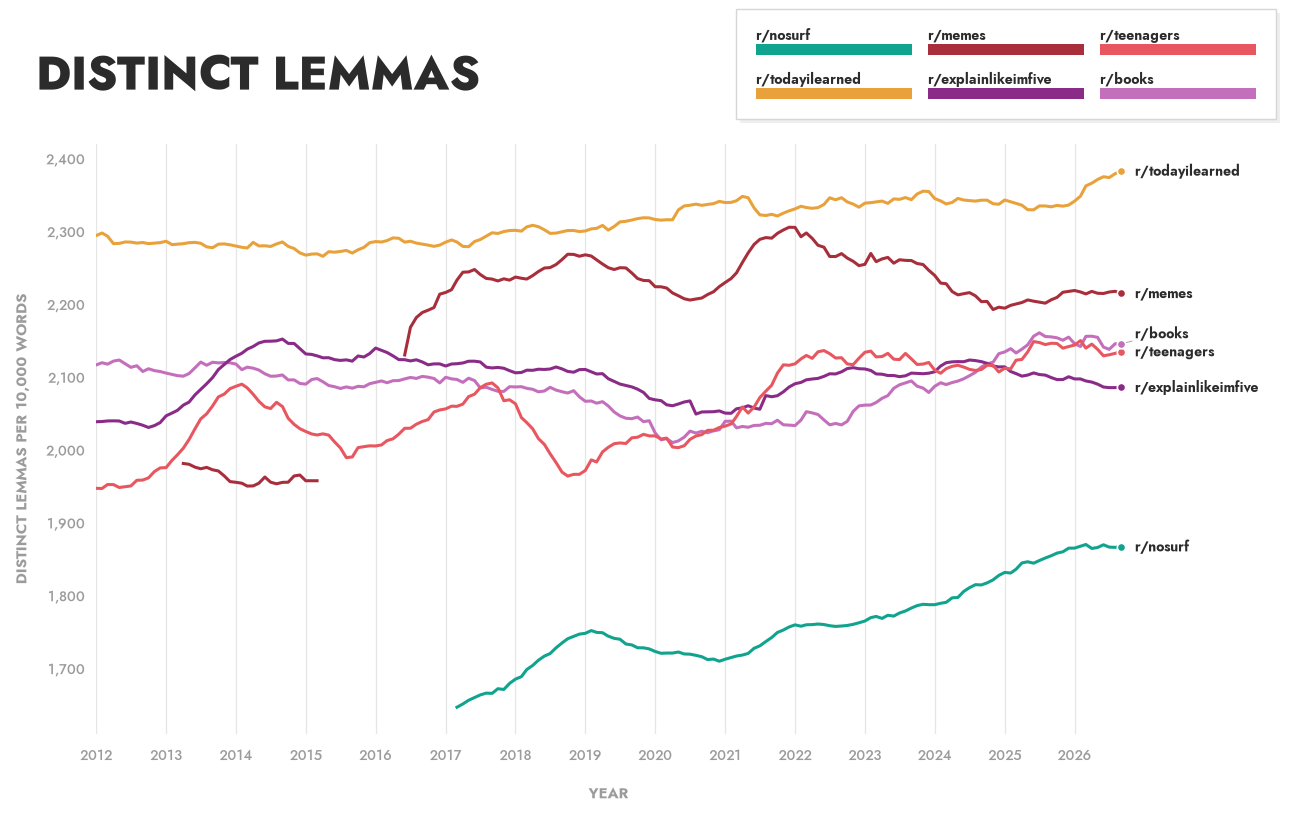

In [15]:
# Needs (once):  pip install spacy  and  python -m spacy download en_core_web_sm
import re
import duckdb
import spacy

CHUNK = 10_000                                     # words per chunk (try 5_000 / 20_000 as a robustness check)
MIN_CHUNKS = 3                                     # a month is shown only if it has at least this many full chunks
BATCHES = 1                                        # use sample batches 1..BATCHES
SEED = "fightclub"                                 # fixes the order of comments -> identical chunks on every computer
BOT_ACCOUNTS = ["AutoModerator", "hive-protect"]   # bots whose names do not end in "bot" (add more if you find them)

DERIVED = Path("data/derived")
DERIVED.mkdir(parents=True, exist_ok=True)
WORDS_FILE = DERIVED / f"comment_words_b{BATCHES}.parquet"   # every comment as a list of cleaned words
LEMMA_FILE = DERIVED / f"lemma_map_b{BATCHES}.parquet"       # word -> normalised word form -> lemma

con = duckdb.connect()
con.sql("SET TimeZone = 'UTC'")
con.sql(f"SET temp_directory = '{(DERIVED / 'duckdb_tmp').as_posix()}'")

# ---- step 1 (one time): clean and split every comment into words -> comment_words.parquet --------------------
if not WORDS_FILE.exists():
    con.sql(rf"""
    COPY (
        SELECT subreddit, strftime(to_timestamp(created_utc), '%Y-%m') AS month, id, author, words
        FROM (
            SELECT *, regexp_extract_all(
                regexp_replace(regexp_replace(regexp_replace(regexp_replace(lower(body),
                    '(^|\n)\s*(&gt;|>)[^\n]*', '\1', 'g'),         -- lines quoted from other comments
                    '\[([^\]]*)\]\([^)]*\)', '\1', 'g'),           -- markdown links: keep only the link text
                    'https?://\S+|www\.\S+|&\w+;', ' ', 'g'),      -- urls and html entities
                    '\b[ru]/\w+', ' ', 'g'),                        -- r/subreddit and u/user mentions
                '[a-z]+(?:''[a-z]+)*') AS words                     -- words: letters, inner apostrophes (don't)
            FROM read_parquet('{(DATA / "comments").as_posix()}/**/*.parquet', hive_partitioning = false)
            WHERE batch <= {BATCHES}
              AND body NOT IN ('[deleted]', '[removed]')
              AND author NOT IN ({', '.join(repr(a) for a in BOT_ACCOUNTS)}) AND lower(author) NOT LIKE '%bot'
              AND coalesce(distinguished, '') <> 'moderator'
              AND body NOT ILIKE '%i am a bot%' AND body NOT ILIKE '%performed automatically%'  -- bot footers
        )
        WHERE len(words) > 0
          -- spam: long comments that repeat the same few words (e.g. one word typed 1,810 times)
          AND NOT (len(words) >= 30 AND len(list_distinct(words)) < 0.2 * len(words))
        -- the same text posted again by the same author in the same month counts only once
        QUALIFY row_number() OVER (PARTITION BY subreddit, month, author, md5(array_to_string(words, ' '))
                                   ORDER BY id) = 1
    ) TO '{WORDS_FILE.as_posix()}' (FORMAT parquet, COMPRESSION zstd)
    """)

# ---- step 2 (one time): lemma of every distinct word -> lemma_map.parquet ------------------------------------
if not LEMMA_FILE.exists():
    forms = con.sql(f"""SELECT form, count(*) AS n
                        FROM (SELECT unnest(words) AS form FROM '{WORDS_FILE.as_posix()}') GROUP BY form""").df()
    stretched = re.compile(r"(.)\1{2,}")
    forms["norm"] = forms["form"].map(lambda w: stretched.sub(r"\1", w))       # sooo -> so, lmaooo -> lmao
    counts = forms.groupby("norm")["n"].sum()
    todo = counts[counts >= 2].index.tolist()          # words seen only once (typos, names) keep their own form
    print(f"Lemmatizing {len(todo):,} distinct words - one time, a few minutes ...")
    nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])
    lemma = {d.text: (d[0].lemma_.lower() if len(d) == 1 else d.text)        # "don't" stays "don't"
             for d in nlp.pipe(todo, batch_size=5_000)}
    forms["lemma"] = forms["norm"].map(lemma).fillna(forms["norm"])
    forms.to_parquet(LEMMA_FILE, index=False)

UNITS = {"lemmas": "lemma", "word_forms": "norm"}  # what is counted -> column of lemma_map


def vocab_by_month(unit):
    """Distinct `unit` per CHUNK words for every subreddit-month. Each month's comments are put in a fixed
    pseudo-random order and cut into consecutive chunks of CHUNK words; the incomplete last chunk is dropped.
    Saves vocab_<unit>_<CHUNK>_b<BATCHES>_chunks.parquet (one row per chunk) and ..._monthly.parquet (one row
    per month). Results already saved for the same settings are loaded instead of recomputed."""
    chunks_file = DERIVED / f"vocab_{unit}_{CHUNK}_b{BATCHES}_chunks.parquet"
    monthly_file = DERIVED / f"vocab_{unit}_{CHUNK}_b{BATCHES}_monthly.parquet"
    if chunks_file.exists() and monthly_file.exists():
        return pd.read_parquet(chunks_file), pd.read_parquet(monthly_file)

    con.sql(f"CREATE OR REPLACE VIEW words AS SELECT * FROM '{WORDS_FILE.as_posix()}'")
    con.sql(f"CREATE OR REPLACE VIEW lemma_map AS SELECT * FROM '{LEMMA_FILE.as_posix()}'")
    parts = []
    for sub, _ in STREAMS:                            # one subreddit at a time keeps memory low
        parts.append(con.sql(f"""
            WITH shuffled AS (
                SELECT month, words,
                       coalesce(sum(len(words)) OVER (PARTITION BY month ORDER BY md5(id || '{SEED}')
                                ROWS BETWEEN UNBOUNDED PRECEDING AND 1 PRECEDING), 0) AS start
                FROM words WHERE subreddit = '{sub}'
            ),
            tokens AS (
                SELECT month, start, unnest(range(len(words))) AS i, unnest(words) AS form FROM shuffled
            ),
            full_chunks AS (
                SELECT month, sum(len(words)) // {CHUNK} AS n FROM words WHERE subreddit = '{sub}' GROUP BY month
            )
            SELECT '{sub}' AS subreddit, t.month, (t.start + t.i) // {CHUNK} AS chunk,
                   count(DISTINCT m.{UNITS[unit]}) AS distinct_n
            FROM tokens t JOIN lemma_map m USING (form) JOIN full_chunks f USING (month)
            WHERE (t.start + t.i) // {CHUNK} < f.n
            GROUP BY ALL
        """).df())
    chunks = pd.concat(parts, ignore_index=True).sort_values(["subreddit", "month", "chunk"])

    sizes = con.sql("SELECT subreddit, month, count(*) AS comments, sum(len(words)) AS words FROM words GROUP BY ALL").df()
    stats = (chunks.groupby(["subreddit", "month"])["distinct_n"]
             .agg(chunks="size", mean="mean", sd="std").reset_index())
    monthly = sizes.merge(stats, on=["subreddit", "month"], how="left").fillna({"chunks": 0})
    monthly["chunks"] = monthly["chunks"].astype(int)
    monthly["ci95"] = 1.96 * monthly["sd"] / np.sqrt(monthly["chunks"].where(monthly["chunks"] > 0))
    monthly["shown"] = monthly["chunks"] >= MIN_CHUNKS
    monthly["month"] = pd.to_datetime(monthly["month"])
    monthly = monthly.sort_values(["subreddit", "month"]).reset_index(drop=True)
    chunks.to_parquet(chunks_file, index=False)
    monthly.to_parquet(monthly_file, index=False)
    return chunks, monthly


def end_labels(ax, ends, min_gap_pt=13):
    """Name at the end of every line (coloured dot + dark text); names that would overlap are moved apart."""
    fig = ax.figure
    fig.canvas.draw()
    px = fig.dpi / 72
    colours = dict(STREAMS)
    placed = None
    for disp, s, x, y in sorted((ax.transData.transform((x, y))[1], s, x, y) for s, (x, y) in ends.items()):
        target = disp if placed is None else max(disp, placed + min_gap_pt * px)
        placed = target
        dy = (target - disp) / px
        ax.plot([x], [y], "o", ms=6, color=colours[s], mec="white", mew=1.2, zorder=5, clip_on=False)
        ax.annotate(f"r/{s}", xy=(x, y), xytext=(10, dy), textcoords="offset points", va="center",
                    fontproperties=font("bold", 10), color=INK, annotation_clip=False,
                    arrowprops=dict(arrowstyle="-", color=AXIS_TEXT, lw=0.6, shrinkA=0, shrinkB=3) if abs(dy) > 2 else None)


def vocab_chart(monthly, title, ylabel):
    """All subreddits on one chart, each as a 12-month moving average of its monthly values."""
    fig, ax = base_figure(title, ylabel)
    W, H = fig.get_size_inches()
    pos = ax.get_position()
    ax.set_position([pos.x0, pos.y0, pos.width - 1.55 / W, pos.height])      # room for the names at the line ends
    months = pd.date_range("2012-01-01", monthly["month"].max(), freq="MS")
    x = mdates.date2num(months)
    ends = {}
    for s, c in STREAMS:
        m = monthly[(monthly["subreddit"] == s) & monthly["shown"]].set_index("month")["mean"].reindex(months)
        trend = m.rolling(12, center=True, min_periods=6).mean()
        ax.plot(x, trend, color=c, linewidth=2.2, zorder=3)
        if trend.notna().any():
            last = trend.last_valid_index()
            ends[s] = (mdates.date2num(last), trend[last])
    style_axes(ax, x, months)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    style_y_labels(ax)
    end_labels(ax, ends)
    plt.show()


lemma_chunks, lemma_monthly = vocab_by_month("lemmas")
print(f"{len(lemma_chunks):,} chunks of {CHUNK:,} words; {lemma_monthly['shown'].sum()} of {len(lemma_monthly)} "
      f"subreddit-months have at least {MIN_CHUNKS} chunks and are shown.")
vocab_chart(lemma_monthly, "DISTINCT LEMMAS", f"DISTINCT LEMMAS PER {CHUNK:,} WORDS")

And now the same measure, but for distict word forms per 10,000 word per month per subreddit.

25,949 chunks of 10,000 words; 968 of 1062 subreddit-months have at least 3 chunks and are shown.


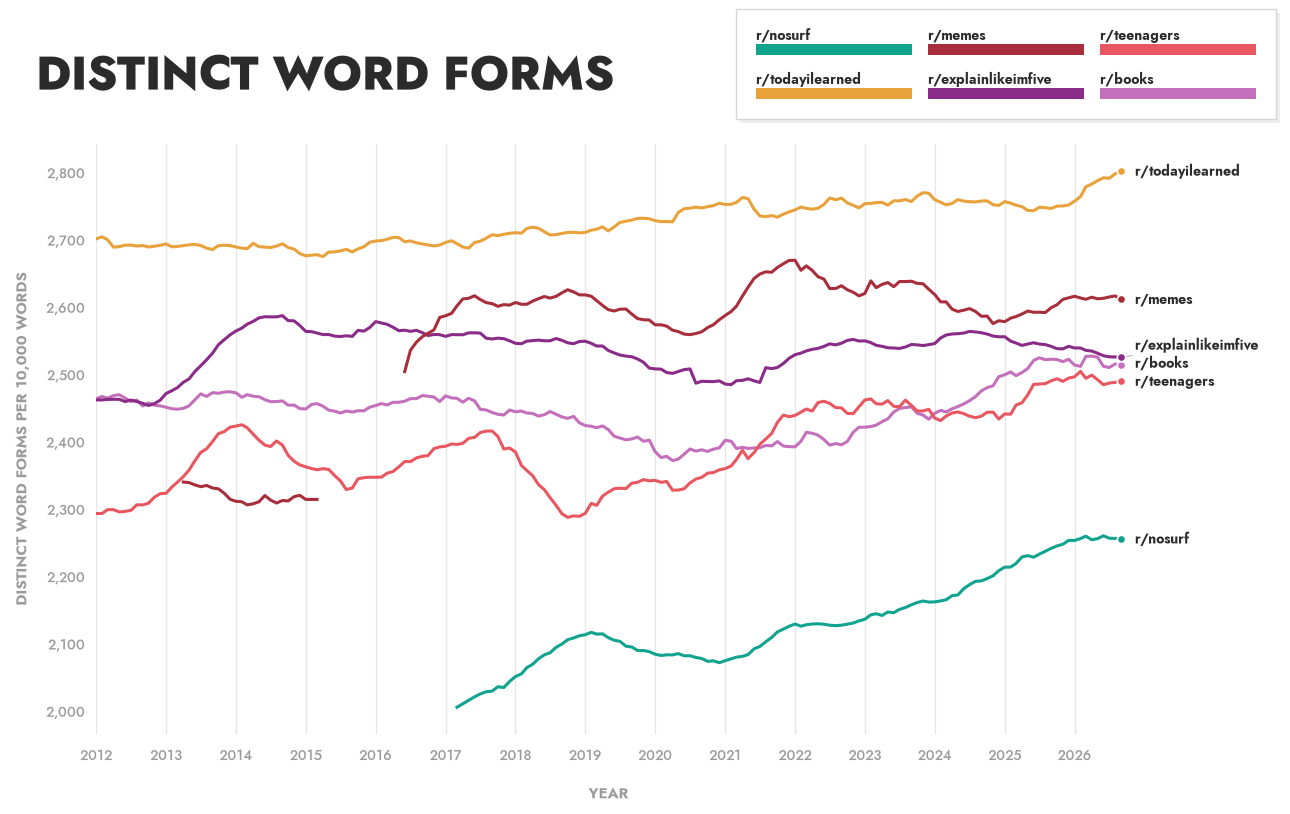

In [16]:
form_chunks, form_monthly = vocab_by_month("word_forms")
print(f"{len(form_chunks):,} chunks of {CHUNK:,} words; {form_monthly['shown'].sum()} of {len(form_monthly)} "
      f"subreddit-months have at least {MIN_CHUNKS} chunks and are shown.")
vocab_chart(form_monthly, "DISTINCT WORD FORMS", f"DISTINCT WORD FORMS PER {CHUNK:,} WORDS")

### 1.3.2. Sentences are getting shorter

### 1.3.3. Lempel-Ziv algorithm

## 1.4. Temporal/Behavioral analysis
Let's analyze conversantions and look into:
1. Thread depth
    1. Thread size
    2. Share or replies vs top-level comments
    3. True depth <!-- download full month for that -->

## H3 probably
> Only Darka works below
Time spent: 5 min

## H4 probably
> Only Ivan works below
Time spent: 0 min